In [20]:
import pandas as pd

In [21]:
df=pd.read_csv("data.csv")

In [22]:
df

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647
...,...,...,...,...
195,0.255081,-0.231497,-0.239632,38.067836
196,0.276068,-0.648411,-0.077441,12.812755
197,0.122250,-1.157383,0.765721,70.454115
198,-0.914822,-0.897140,-0.784205,-93.235783


Linear relation between input and output column

<Axes: xlabel='feature1', ylabel='target'>

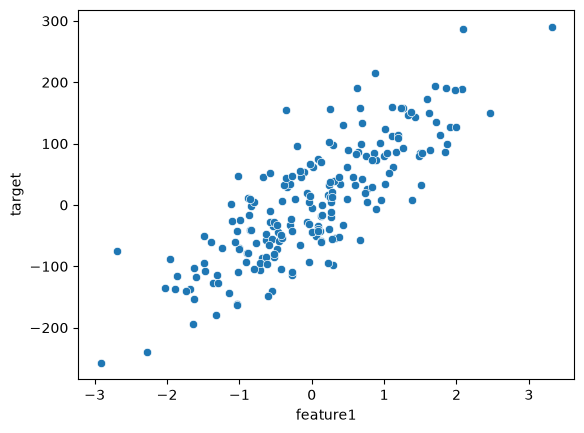

In [23]:
import seaborn as sns
sns.scatterplot(x=df["feature1"],y=df["target"])

<Axes: xlabel='feature2', ylabel='target'>

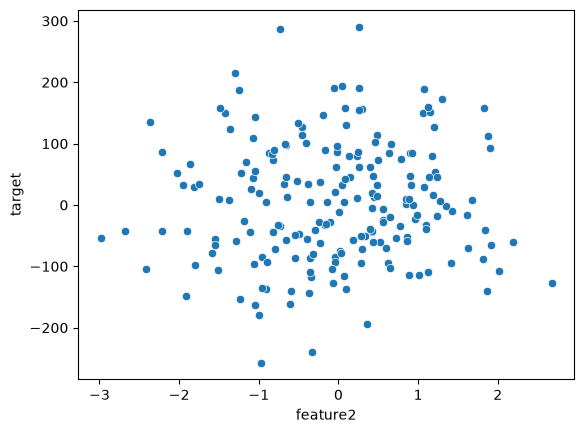

In [24]:
sns.scatterplot(x=df["feature2"],y=df["target"])

<Axes: xlabel='feature3', ylabel='target'>

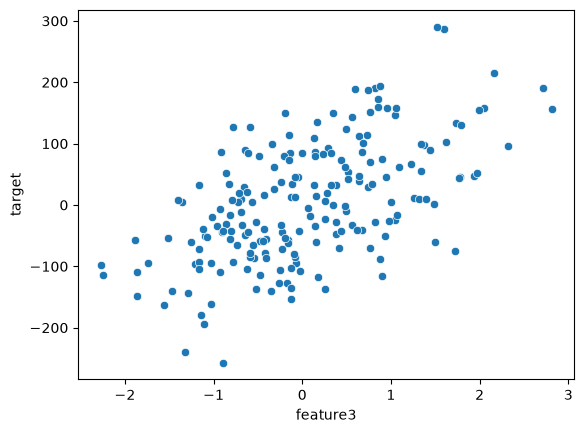

In [25]:
sns.scatterplot(x=df["feature3"],y=df["target"])

In [26]:
# seperate input and output variables
x=df.drop(columns=["target"])
y=df[["target"]]

In [27]:
x

,feature1,feature2,feature3
0,-0.570563,1.420342,0.495580
1,-0.990563,0.556965,1.045064
2,-0.674728,0.150617,1.774645
3,0.388250,-0.387127,-0.110229
4,1.167882,-0.024104,0.145063
...,...,...,...
195,0.255081,-0.231497,-0.239632
196,0.276068,-0.648411,-0.077441
197,0.122250,-1.157383,0.765721
198,-0.914822,-0.897140,-0.784205


In [28]:
y

,target
0,-9.763182
1,-24.029355
2,45.616421
3,34.135737
4,86.663647
...,...
195,38.067836
196,12.812755
197,70.454115
198,-93.235783


In [29]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

No Multicollinearity

In [30]:
# How to detect ----> VIF (variance Inflation Factor)
'''
Syntax:

variance_inflation_factor(X, feature_index)

where:

X → matrix containing all independent variables (features)
feature_index → the column number whose VIF you want to calculate

'''
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(x_train.shape[1]):
    vif.append(variance_inflation_factor(x_train, i))
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.003424,1.002465,1.004347


<Axes: >

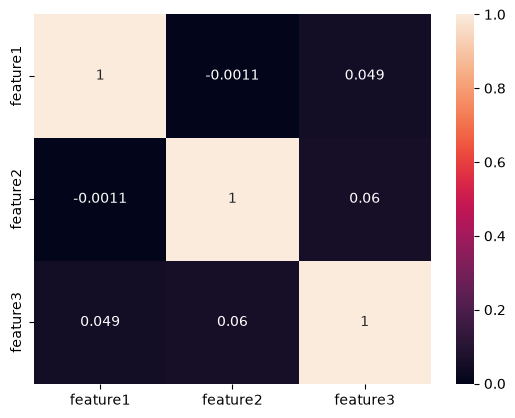

In [35]:
# We can also detect multicollinearity using heatmap
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)


Normality of residual

<Axes: ylabel='Count'>

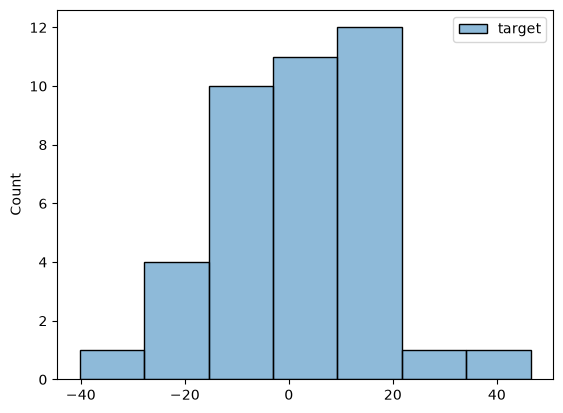

In [ ]:
# can be detected by drawing histogram of reisudals

'''
residual = error = y_true - y_predicted

ASSUMPTION ---> residual should follow approximately normal distribution.

'''

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

y_predicted=model.predict(x_test) 


residual=y_test-y_predicted # error/residual
sns.histplot(residual)



Homoscedasticity

In [ ]:
'''
 variance of the error terms (residuals) remains constant across
 all levels of the independent variable.
 
 '''